In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (815).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (777).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (196).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (722).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (590).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (988).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (134).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (900).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (604).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (483).jpg
/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images/healthy_leaf/h1 (245).jpg
/kaggle/input/datasets/rubab123/aloe-vera-i

In [2]:
import os
import torch

DATA_DIR = "/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images"
CLASS_NAMES = ["healthy_leaf", "rot", "rust"]

print("Folders found:", sorted(os.listdir(DATA_DIR)))
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Folders found: ['healthy_leaf', 'rot', 'rust']
GPU available: True
GPU name: Tesla T4


In [3]:
!pip install -q timm
import timm
print(timm.__version__)

1.0.26


In [4]:
import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import timm
from tqdm import tqdm

DATA_DIR = "/kaggle/input/datasets/rubab123/aloe-vera-images/crop_images"
CLASS_NAMES = ["healthy_leaf", "rot", "rust"]
NUM_CLASSES = len(CLASS_NAMES)
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Ready. Using device:", DEVICE)

Ready. Using device: cuda


In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def stratified_split_indices(targets, val_fraction, test_fraction, seed):
    targets = np.asarray(targets)
    all_idx = np.arange(len(targets))
    holdout_fraction = val_fraction + test_fraction
    train_idx, holdout_idx = train_test_split(
        all_idx, test_size=holdout_fraction, stratify=targets, random_state=seed
    )
    holdout_targets = targets[holdout_idx]
    relative_test_fraction = test_fraction / holdout_fraction
    val_idx, test_idx = train_test_split(
        holdout_idx, test_size=relative_test_fraction, stratify=holdout_targets, random_state=seed
    )
    return train_idx.tolist(), val_idx.tolist(), test_idx.tolist()

def compute_class_weights_fn(targets, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(targets))
    return torch.tensor(weights, dtype=torch.float32)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_transforms(img_size):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_transform, eval_transform

def get_dataloaders(img_size, batch_size, num_workers=2):
    train_transform, eval_transform = build_transforms(img_size)
    train_view = datasets.ImageFolder(DATA_DIR, transform=train_transform)
    eval_view = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

    if train_view.classes != CLASS_NAMES:
        raise ValueError(f"Found classes {train_view.classes}, expected {CLASS_NAMES}")

    targets = [label for _, label in train_view.samples]
    train_idx, val_idx, test_idx = stratified_split_indices(targets, VAL_FRACTION, TEST_FRACTION, SEED)

    train_ds = Subset(train_view, train_idx)
    val_ds = Subset(eval_view, val_idx)
    test_ds = Subset(eval_view, test_idx)

    train_targets = [targets[i] for i in train_idx]
    class_weights = compute_class_weights_fn(train_targets, NUM_CLASSES)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"Dataset split -> train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")
    print(f"Classes (index order): {train_view.classes}")
    return train_loader, val_loader, test_loader, class_weights

set_seed(SEED)
train_loader, val_loader, test_loader, class_weights = get_dataloaders(img_size=192, batch_size=32)
print("Class weights:", class_weights)

Dataset split -> train: 2446  val: 524  test: 525
Classes (index order): ['healthy_leaf', 'rot', 'rust']
Class weights: tensor([1.1277, 1.0386, 0.8692])


In [6]:
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

def build_model(backbone_name, num_classes, pretrained=True):
    model = timm.create_model(backbone_name, pretrained=pretrained, num_classes=num_classes)
    return model.to(DEVICE)

def run_epoch(model, loader, criterion, optimizer, scaler, train, amp_enabled):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    grad_context = torch.enable_grad() if train else torch.no_grad()
    with grad_context:
        for images, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1

def train_backbone(backbone_name, train_loader, val_loader, class_weights,
                    epochs=20, lr=1e-4, weight_decay=1e-4,
                    early_stopping_patience=5, lr_patience=2):
    amp_enabled = (DEVICE.type == "cuda")
    model = build_model(backbone_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=lr_patience)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    checkpoint_path = f"/kaggle/working/checkpoints/{backbone_name}_best.pt"
    best_val_f1 = -1.0
    epochs_without_improvement = 0
    history = []

    print(f"\n=== Training {backbone_name} on {DEVICE} | amp={amp_enabled} ===")
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_f1 = run_epoch(model, train_loader, criterion, optimizer, scaler, True, amp_enabled)
        val_loss, val_f1 = run_epoch(model, val_loader, criterion, optimizer, scaler, False, amp_enabled)
        scheduler.step(val_f1)
        elapsed = time.time() - start
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
              f"val_loss={val_loss:.4f} val_f1={val_f1:.4f} | {elapsed:.1f}s")
        history.append({"epoch": epoch, "train_loss": train_loss, "train_f1": train_f1,
                         "val_loss": val_loss, "val_f1": val_f1})
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_without_improvement = 0
            torch.save({"model_state_dict": model.state_dict(), "backbone": backbone_name,
                        "val_f1": val_f1}, checkpoint_path)
            print(f"  -> new best saved (val_f1={val_f1:.4f})")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"No improvement for {early_stopping_patience} epochs -- stopping early.")
                break

    print(f"Done. Best val macro-F1 for {backbone_name}: {best_val_f1:.4f}")
    return checkpoint_path, best_val_f1, history

print("Training functions ready.")

Training functions ready.


In [7]:
checkpoint_path, best_val_f1, history = train_backbone(
    backbone_name="mobilenetv2_100",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=20,
)

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

/tmp/ipykernel_58/1623123428.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training mobilenetv2_100 on cuda | amp=True ===


Epoch 01/20 | train_loss=1.8532 train_f1=0.6002 | val_loss=1.0067 val_f1=0.7281 | 29.3s
  -> new best saved (val_f1=0.7281)


Epoch 02/20 | train_loss=0.6365 train_f1=0.8141 | val_loss=0.5239 val_f1=0.8139 | 9.8s
  -> new best saved (val_f1=0.8139)


...

Epoch 15/20 | train_loss=0.0726 train_f1=0.9768 | val_loss=0.1074 val_f1=0.9589 | 9.8s


Epoch 16/20 | train_loss=0.0727 train_f1=0.9767 | val_loss=0.0761 val_f1=0.9850 | 9.5s


Epoch 17/20 | train_loss=0.0593 train_f1=0.9829 | val_loss=0.0742 val_f1=0.9830 | 9.7s


Epoch 18/20 | train_loss=0.0470 train_f1=0.9809 | val_loss=0.0707 val_f1=0.9792 | 9.6s


Epoch 19/20 | train_loss=0.0638 train_f1=0.9773 | val_loss=0.0625 val_f1=0.9832 | 9.9s
No improvement for 5 epochs -- stopping early.
Done. Best val macro-F1 for mobilenetv2_100: 0.9852


In [8]:
def evaluate_on_test(checkpoint_path, backbone_name, test_loader):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model = build_model(backbone_name, NUM_CLASSES)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    cm = confusion_matrix(all_labels, all_preds)
    print(f"\n=== {backbone_name} -- TEST SET ===")
    print(f"Test accuracy: {acc:.4f}\n")
    print(report)
    return acc, report, cm

results = {}  #collecting every backbone's results here
acc, report, cm = evaluate_on_test(checkpoint_path, "mobilenetv2_100", test_loader)
results["mobilenetv2_100"] = {"test_accuracy": acc, "report": report, "confusion_matrix": cm, "val_f1": best_val_f1}


=== mobilenetv2_100 -- TEST SET ===
Test accuracy: 0.9771

              precision    recall  f1-score   support

healthy_leaf     0.9747    0.9935    0.9840       155
         rot     0.9877    0.9527    0.9699       169
        rust     0.9706    0.9851    0.9778       201

    accuracy                         0.9771       525
   macro avg     0.9777    0.9771    0.9772       525
weighted avg     0.9773    0.9771    0.9771       525



In [9]:
checkpoint_path_b0, best_val_f1_b0, history_b0 = train_backbone(
    backbone_name="efficientnet_b0",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=20,
)

acc_b0, report_b0, cm_b0 = evaluate_on_test(checkpoint_path_b0, "efficientnet_b0", test_loader)
results["efficientnet_b0"] = {"test_accuracy": acc_b0, "report": report_b0, "confusion_matrix": cm_b0, "val_f1": best_val_f1_b0}

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipykernel_58/1623123428.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training efficientnet_b0 on cuda | amp=True ===


Epoch 01/20 | train_loss=1.4273 train_f1=0.6835 | val_loss=0.6277 val_f1=0.8186 | 22.1s
  -> new best saved (val_f1=0.8186)


Epoch 02/20 | train_loss=0.4403 train_f1=0.8733 | val_loss=0.3554 val_f1=0.8884 | 9.8s
  -> new best saved (val_f1=0.8884)


...

Epoch 16/20 | train_loss=0.0391 train_f1=0.9855 | val_loss=0.0696 val_f1=0.9778 | 10.0s


Epoch 17/20 | train_loss=0.0228 train_f1=0.9898 | val_loss=0.0708 val_f1=0.9833 | 10.0s
  -> new best saved (val_f1=0.9833)


Epoch 18/20 | train_loss=0.0312 train_f1=0.9889 | val_loss=0.0742 val_f1=0.9815 | 10.1s


Epoch 19/20 | train_loss=0.0389 train_f1=0.9852 | val_loss=0.0932 val_f1=0.9777 | 9.9s


Epoch 20/20 | train_loss=0.0345 train_f1=0.9883 | val_loss=0.1671 val_f1=0.9576 | 10.1s
Done. Best val macro-F1 for efficientnet_b0: 0.9833

=== efficientnet_b0 -- TEST SET ===
Test accuracy: 0.9733

              precision    recall  f1-score   support

healthy_leaf     1.0000    0.9806    0.9902       155
         rot     0.9435    0.9882    0.9653       169
        rust     0.9796    0.9552    0.9673       201

    accuracy                         0.9733       525
   macro avg     0.9744    0.9747    0.9743       525
weighted avg     0.9740    0.9733    0.9734       525



In [10]:
checkpoint_path_r18, best_val_f1_r18, history_r18 = train_backbone(
    backbone_name="resnet18",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=20,
)

acc_r18, report_r18, cm_r18 = evaluate_on_test(checkpoint_path_r18, "resnet18", test_loader)
results["resnet18"] = {"test_accuracy": acc_r18, "report": report_r18, "confusion_matrix": cm_r18, "val_f1": best_val_f1_r18}

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/tmp/ipykernel_58/1623123428.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training resnet18 on cuda | amp=True ===


Epoch 01/20 | train_loss=0.9968 train_f1=0.5772 | val_loss=0.8602 val_f1=0.7671 | 9.4s
  -> new best saved (val_f1=0.7671)


Epoch 02/20 | train_loss=0.6941 train_f1=0.7698 | val_loss=0.4926 val_f1=0.8500 | 9.4s
  -> new best saved (val_f1=0.8500)


...

Epoch 16/20 | train_loss=0.0520 train_f1=0.9816 | val_loss=0.0529 val_f1=0.9851 | 9.4s
  -> new best saved (val_f1=0.9851)


Epoch 17/20 | train_loss=0.0574 train_f1=0.9829 | val_loss=0.0577 val_f1=0.9831 | 9.5s


Epoch 18/20 | train_loss=0.0526 train_f1=0.9822 | val_loss=0.0562 val_f1=0.9851 | 9.5s


Epoch 19/20 | train_loss=0.0477 train_f1=0.9835 | val_loss=0.0528 val_f1=0.9815 | 9.3s


Epoch 20/20 | train_loss=0.0473 train_f1=0.9856 | val_loss=0.0516 val_f1=0.9851 | 9.6s
Done. Best val macro-F1 for resnet18: 0.9851

=== resnet18 -- TEST SET ===
Test accuracy: 0.9714

              precision    recall  f1-score   support

healthy_leaf     0.9935    0.9935    0.9935       155
         rot     0.9695    0.9408    0.9550       169
        rust     0.9563    0.9801    0.9681       201

    accuracy                         0.9714       525
   macro avg     0.9731    0.9715    0.9722       525
weighted avg     0.9716    0.9714    0.9714       525



In [11]:
train_loader_b3, val_loader_b3, test_loader_b3, class_weights_b3 = get_dataloaders(img_size=250, batch_size=24)

checkpoint_path_b3, best_val_f1_b3, history_b3 = train_backbone(
    backbone_name="efficientnet_b3",
    train_loader=train_loader_b3,
    val_loader=val_loader_b3,
    class_weights=class_weights_b3,
    epochs=20,
)

acc_b3, report_b3, cm_b3 = evaluate_on_test(checkpoint_path_b3, "efficientnet_b3", test_loader_b3)
results["efficientnet_b3"] = {"test_accuracy": acc_b3, "report": report_b3, "confusion_matrix": cm_b3, "val_f1": best_val_f1_b3}

Dataset split -> train: 2446  val: 524  test: 525
Classes (index order): ['healthy_leaf', 'rot', 'rust']


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_58/1623123428.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training efficientnet_b3 on cuda | amp=True ===


Epoch 01/20 | train_loss=0.9359 train_f1=0.7235 | val_loss=0.4131 val_f1=0.8460 | 44.6s
  -> new best saved (val_f1=0.8460)


...

Epoch 15/20 | train_loss=0.0314 train_f1=0.9921 | val_loss=0.0364 val_f1=0.9924 | 19.1s


Epoch 16/20 | train_loss=0.0333 train_f1=0.9875 | val_loss=0.0432 val_f1=0.9883 | 19.1s


Epoch 17/20 | train_loss=0.0194 train_f1=0.9920 | val_loss=0.0416 val_f1=0.9865 | 19.1s


Epoch 18/20 | train_loss=0.0202 train_f1=0.9925 | val_loss=0.0352 val_f1=0.9865 | 19.0s


Epoch 19/20 | train_loss=0.0168 train_f1=0.9933 | val_loss=0.0333 val_f1=0.9906 | 19.1s
No improvement for 5 epochs -- stopping early.
Done. Best val macro-F1 for efficientnet_b3: 0.9927

=== efficientnet_b3 -- TEST SET ===
Test accuracy: 0.9752

              precision    recall  f1-score   support

healthy_leaf     1.0000    0.9742    0.9869       155
         rot     0.9483    0.9763    0.9621       169
        rust     0.9800    0.9751    0.9776       201

    accuracy                         0.9752       525
   macro avg     0.9761    0.9752    0.9755       525
weighted avg     0.9757    0.9752    0.9753       525



In [12]:
# Reuse the EXACT same train/val/test split already used for the flat models,
base_dataset = train_loader.dataset.dataset
train_idx = train_loader.dataset.indices
val_idx = val_loader.dataset.indices
test_idx = test_loader.dataset.indices

all_targets = np.array([label for _, label in base_dataset.samples])

# Stage 1 label: 0 = healthy, 1 = diseased (rot OR rust merged together)
def to_stage1_label(original_label):
    return 0 if original_label == 0 else 1

stage1_targets = np.array([to_stage1_label(t) for t in all_targets])

print("Stage 1 label counts (0=healthy, 1=diseased):")
for split_name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    counts = np.bincount(stage1_targets[idx], minlength=2)
    print(f"  {split_name}: healthy={counts[0]}  diseased={counts[1]}")

# Stage 2 only looks at images that are ACTUALLY diseased, within each split
def stage2_indices(idx):
    return [i for i in idx if all_targets[i] != 0]

stage2_train_idx = stage2_indices(train_idx)
stage2_val_idx = stage2_indices(val_idx)
stage2_test_idx = stage2_indices(test_idx)

def to_stage2_label(original_label):
    return original_label - 1  # 1 (rot) -> 0,   2 (rust) -> 1

print("\nStage 2 label counts (0=rot, 1=rust), diseased images only:")
for split_name, idx in [("train", stage2_train_idx), ("val", stage2_val_idx), ("test", stage2_test_idx)]:
    labels = [to_stage2_label(all_targets[i]) for i in idx]
    counts = np.bincount(labels, minlength=2)
    print(f"  {split_name}: rot={counts[0]}  rust={counts[1]}")

Stage 1 label counts (0=healthy, 1=diseased):
  train: healthy=723  diseased=1723
  val: healthy=155  diseased=369
  test: healthy=155  diseased=370

Stage 2 label counts (0=rot, 1=rust), diseased images only:
  train: rot=785  rust=938
  val: rot=168  rust=201
  test: rot=169  rust=201


In [13]:
class RemappedLabelDataset(torch.utils.data.Dataset):
    """Reuses the same images, but swaps in a different label -- turning the 3-class problem into a 2-class problem without duplicating any files."""
    def __init__(self, base_dataset, indices, label_map_fn):
        self.base_dataset = base_dataset
        self.indices = indices
        self.label_map_fn = label_map_fn

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        image, original_label = self.base_dataset[real_idx]
        return image, self.label_map_fn(original_label)


def train_backbone(backbone_name, train_loader, val_loader, class_weights,
                    num_classes=NUM_CLASSES, checkpoint_tag=None,
                    epochs=20, lr=1e-4, weight_decay=1e-4,
                    early_stopping_patience=5, lr_patience=2):
    amp_enabled = (DEVICE.type == "cuda")
    model = build_model(backbone_name, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=lr_patience)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    tag = checkpoint_tag or backbone_name
    checkpoint_path = f"/kaggle/working/checkpoints/{tag}_best.pt"
    best_val_f1 = -1.0
    epochs_without_improvement = 0

    print(f"\n=== Training {tag} ({backbone_name}, {num_classes}-class) on {DEVICE} ===")
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_f1 = run_epoch(model, train_loader, criterion, optimizer, scaler, True, amp_enabled)
        val_loss, val_f1 = run_epoch(model, val_loader, criterion, optimizer, scaler, False, amp_enabled)
        scheduler.step(val_f1)
        elapsed = time.time() - start
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
              f"val_loss={val_loss:.4f} val_f1={val_f1:.4f} | {elapsed:.1f}s")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_without_improvement = 0
            torch.save({"model_state_dict": model.state_dict(), "backbone": backbone_name,
                        "num_classes": num_classes, "val_f1": val_f1}, checkpoint_path)
            print(f"  -> new best saved (val_f1={val_f1:.4f})")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"No improvement for {early_stopping_patience} epochs -- stopping early.")
                break

    print(f"Done. Best val macro-F1 for {tag}: {best_val_f1:.4f}")
    return checkpoint_path, best_val_f1, history if False else None


def evaluate_on_test_generic(checkpoint_path, backbone_name, num_classes, class_names, test_loader):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model = build_model(backbone_name, num_classes)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    cm = confusion_matrix(all_labels, all_preds)
    print(f"\n=== {backbone_name} -- TEST SET ({', '.join(class_names)}) ===")
    print(f"Test accuracy: {acc:.4f}\n")
    print(report)
    return acc, report, cm, all_preds, all_labels

print("Stage 1/2 helper functions ready.")

Stage 1/2 helper functions ready.


In [14]:
train_view = train_loader.dataset.dataset
eval_view = val_loader.dataset.dataset

stage1_train_ds = RemappedLabelDataset(train_view, train_idx, to_stage1_label)
stage1_val_ds = RemappedLabelDataset(eval_view, val_idx, to_stage1_label)
stage1_test_ds = RemappedLabelDataset(eval_view, test_idx, to_stage1_label)

stage1_train_loader = DataLoader(stage1_train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
stage1_val_loader = DataLoader(stage1_val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
stage1_test_loader = DataLoader(stage1_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

stage1_train_labels = [to_stage1_label(all_targets[i]) for i in train_idx]
stage1_class_weights = compute_class_weights_fn(stage1_train_labels, num_classes=2)
print("Stage 1 class weights (healthy, diseased):", stage1_class_weights)

stage1_checkpoint, stage1_best_val_f1, _ = train_backbone(
    backbone_name="mobilenetv2_100",
    train_loader=stage1_train_loader,
    val_loader=stage1_val_loader,
    class_weights=stage1_class_weights,
    num_classes=2,
    checkpoint_tag="stage1_healthy_vs_diseased",
    epochs=20,
)

stage1_acc, stage1_report, stage1_cm, stage1_preds, stage1_labels = evaluate_on_test_generic(
    stage1_checkpoint, "mobilenetv2_100", num_classes=2,
    class_names=["healthy", "diseased"], test_loader=stage1_test_loader
)

Stage 1 class weights (healthy, diseased): tensor([1.6916, 0.7098])


/tmp/ipykernel_58/2303366172.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training stage1_healthy_vs_diseased (mobilenetv2_100, 2-class) on cuda ===


Epoch 01/20 | train_loss=1.0856 train_f1=0.7253 | val_loss=0.8041 val_f1=0.7760 | 9.9s
  -> new best saved (val_f1=0.7760)


Epoch 02/20 | train_loss=0.2821 train_f1=0.9033 | val_loss=0.2445 val_f1=0.9188 | 9.7s
  -> new best saved (val_f1=0.9188)


...

Epoch 11/20 | train_loss=0.0459 train_f1=0.9853 | val_loss=0.0322 val_f1=0.9841 | 9.7s


Epoch 12/20 | train_loss=0.0270 train_f1=0.9912 | val_loss=0.0498 val_f1=0.9819 | 9.8s


Epoch 13/20 | train_loss=0.0286 train_f1=0.9917 | val_loss=0.0579 val_f1=0.9775 | 9.7s


Epoch 14/20 | train_loss=0.0279 train_f1=0.9873 | val_loss=0.0622 val_f1=0.9775 | 9.7s


Epoch 15/20 | train_loss=0.0362 train_f1=0.9907 | val_loss=0.0445 val_f1=0.9796 | 9.8s
No improvement for 5 epochs -- stopping early.
Done. Best val macro-F1 for stage1_healthy_vs_diseased: 0.9886

=== mobilenetv2_100 -- TEST SET (healthy, diseased) ===
Test accuracy: 0.9867

              precision    recall  f1-score   support

     healthy     0.9684    0.9871    0.9776       155
    diseased     0.9946    0.9865    0.9905       370

    accuracy                         0.9867       525
   macro avg     0.9815    0.9868    0.9841       525
weighted avg     0.9868    0.9867    0.9867       525



In [15]:
stage2_train_ds = RemappedLabelDataset(train_view, stage2_train_idx, to_stage2_label)
stage2_val_ds = RemappedLabelDataset(eval_view, stage2_val_idx, to_stage2_label)
stage2_test_ds = RemappedLabelDataset(eval_view, stage2_test_idx, to_stage2_label)

stage2_train_loader = DataLoader(stage2_train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
stage2_val_loader = DataLoader(stage2_val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
stage2_test_loader = DataLoader(stage2_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

stage2_train_labels = [to_stage2_label(all_targets[i]) for i in stage2_train_idx]
stage2_class_weights = compute_class_weights_fn(stage2_train_labels, num_classes=2)
print("Stage 2 class weights (rot, rust):", stage2_class_weights)

stage2_checkpoint, stage2_best_val_f1, _ = train_backbone(
    backbone_name="mobilenetv2_100",
    train_loader=stage2_train_loader,
    val_loader=stage2_val_loader,
    class_weights=stage2_class_weights,
    num_classes=2,
    checkpoint_tag="stage2_rot_vs_rust",
    epochs=20,
)

stage2_acc, stage2_report, stage2_cm, stage2_preds, stage2_labels = evaluate_on_test_generic(
    stage2_checkpoint, "mobilenetv2_100", num_classes=2,
    class_names=["rot", "rust"], test_loader=stage2_test_loader
)

Stage 2 class weights (rot, rust): tensor([1.0975, 0.9184])


/tmp/ipykernel_58/2303366172.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)



=== Training stage2_rot_vs_rust (mobilenetv2_100, 2-class) on cuda ===


Epoch 01/20 | train_loss=1.5513 train_f1=0.6893 | val_loss=1.0751 val_f1=0.8041 | 16.3s
  -> new best saved (val_f1=0.8041)


Epoch 02/20 | train_loss=0.6026 train_f1=0.8410 | val_loss=0.6732 val_f1=0.8393 | 6.8s
  -> new best saved (val_f1=0.8393)


...

Epoch 11/20 | train_loss=0.0967 train_f1=0.9655 | val_loss=0.2134 val_f1=0.9429 | 6.9s


Epoch 12/20 | train_loss=0.1065 train_f1=0.9632 | val_loss=0.1644 val_f1=0.9483 | 6.9s


Epoch 13/20 | train_loss=0.1289 train_f1=0.9632 | val_loss=0.1886 val_f1=0.9510 | 6.8s


Epoch 14/20 | train_loss=0.0821 train_f1=0.9719 | val_loss=0.1716 val_f1=0.9428 | 7.0s


Epoch 15/20 | train_loss=0.0796 train_f1=0.9707 | val_loss=0.1637 val_f1=0.9510 | 6.8s
No improvement for 5 epochs -- stopping early.
Done. Best val macro-F1 for stage2_rot_vs_rust: 0.9563

=== mobilenetv2_100 -- TEST SET (rot, rust) ===
Test accuracy: 0.9351

              precision    recall  f1-score   support

         rot     0.9096    0.9527    0.9306       169
        rust     0.9585    0.9204    0.9391       201

    accuracy                         0.9351       370
   macro avg     0.9341    0.9365    0.9349       370
weighted avg     0.9362    0.9351    0.9352       370



In [16]:
full_test_ds = torch.utils.data.Subset(eval_view, test_idx)
full_test_loader = DataLoader(full_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

stage2_ckpt_data = torch.load(stage2_checkpoint, map_location=DEVICE)
stage2_model = build_model("mobilenetv2_100", 2)
stage2_model.load_state_dict(stage2_ckpt_data["model_state_dict"])
stage2_model.eval()

stage2_preds_all = []
with torch.no_grad():
    for images, _ in full_test_loader:
        images = images.to(DEVICE)
        outputs = stage2_model(images)
        stage2_preds_all.extend(outputs.argmax(dim=1).cpu().tolist())
stage2_preds_all = np.array(stage2_preds_all)

stage1_preds_arr = np.array(stage1_preds)  # already computed earlier, same order as test_idx

pipeline_preds = np.where(
    stage1_preds_arr == 0,
    0,                                            # Stage 1 says healthy -> final = healthy
    np.where(stage2_preds_all == 0, 1, 2)         # Stage 1 says diseased -> Stage 2 decides rot(1) or rust(2)
)

true_labels_full = all_targets[test_idx]

pipeline_acc = accuracy_score(true_labels_full, pipeline_preds)
pipeline_report = classification_report(true_labels_full, pipeline_preds, target_names=CLASS_NAMES, digits=4)
pipeline_cm = confusion_matrix(true_labels_full, pipeline_preds)

print("=== TWO-STAGE PIPELINE -- FULL TEST SET (525 images) ===")
print(f"Pipeline accuracy: {pipeline_acc:.4f}\n")
print(pipeline_report)
print("\nConfusion matrix:\n", pipeline_cm)
print(f"\nFor comparison -- flat MobileNetV2 test accuracy was: {results['mobilenetv2_100']['test_accuracy']:.4f}")

=== TWO-STAGE PIPELINE -- FULL TEST SET (525 images) ===
Pipeline accuracy: 0.9410

              precision    recall  f1-score   support

healthy_leaf     0.9684    0.9871    0.9776       155
         rot     0.8977    0.9349    0.9159       169
        rust     0.9581    0.9104    0.9337       201

    accuracy                         0.9410       525
   macro avg     0.9414    0.9442    0.9424       525
weighted avg     0.9417    0.9410    0.9409       525


Confusion matrix:
 [[153   2   0]
 [  3 158   8]
 [  2  16 183]]

For comparison -- flat MobileNetV2 test accuracy was: 0.9771


In [17]:
def get_probs(checkpoint_path, backbone_name, num_classes, loader):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model = build_model(backbone_name, num_classes)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)

stage1_probs = get_probs(stage1_checkpoint, "mobilenetv2_100", 2, full_test_loader)  # [healthy, diseased]
stage2_probs = get_probs(stage2_checkpoint, "mobilenetv2_100", 2, full_test_loader)  # [rot, rust]

p_healthy = stage1_probs[:, 0]
p_rot = stage1_probs[:, 1] * stage2_probs[:, 0]
p_rust = stage1_probs[:, 1] * stage2_probs[:, 1]

soft_preds = np.stack([p_healthy, p_rot, p_rust], axis=1).argmax(axis=1)

soft_acc = accuracy_score(true_labels_full, soft_preds)
print("=== SOFT (PROBABILITY-WEIGHTED) PIPELINE ===")
print(f"Accuracy: {soft_acc:.4f}\n")
print(classification_report(true_labels_full, soft_preds, target_names=CLASS_NAMES, digits=4))
print(f"\nHard-cascade pipeline: {pipeline_acc:.4f}  |  Flat MobileNetV2: {results['mobilenetv2_100']['test_accuracy']:.4f}")

=== SOFT (PROBABILITY-WEIGHTED) PIPELINE ===
Accuracy: 0.9410

              precision    recall  f1-score   support

healthy_leaf     0.9623    0.9871    0.9745       155
         rot     0.8977    0.9349    0.9159       169
        rust     0.9632    0.9104    0.9361       201

    accuracy                         0.9410       525
   macro avg     0.9410    0.9442    0.9422       525
weighted avg     0.9418    0.9410    0.9409       525


Hard-cascade pipeline: 0.9410  |  Flat MobileNetV2: 0.9771


In [18]:
def get_probs_flat(checkpoint_path, backbone_name, loader):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model = build_model(backbone_name, NUM_CLASSES)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            all_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
    return np.concatenate(all_probs, axis=0)

probs_mnv2 = get_probs_flat("/kaggle/working/checkpoints/mobilenetv2_100_best.pt", "mobilenetv2_100", test_loader)
probs_b0 = get_probs_flat("/kaggle/working/checkpoints/efficientnet_b0_best.pt", "efficientnet_b0", test_loader)
probs_r18 = get_probs_flat("/kaggle/working/checkpoints/resnet18_best.pt", "resnet18", test_loader)
probs_b3 = get_probs_flat(checkpoint_path_b3, "efficientnet_b3", test_loader_b3)

ensemble_probs = (probs_mnv2 + probs_b0 + probs_r18 + probs_b3) / 4
ensemble_preds = ensemble_probs.argmax(axis=1)

true_labels_flat = np.array([label for _, label in test_loader.dataset])
ensemble_acc = accuracy_score(true_labels_flat, ensemble_preds)

print(f"Ensemble accuracy: {ensemble_acc:.4f}")
print(f"Best single model (MobileNetV2): {results['mobilenetv2_100']['test_accuracy']:.4f}")

Ensemble accuracy: 0.9886
Best single model (MobileNetV2): 0.9771


In [19]:
print("=== ENSEMBLE -- FULL CLASSIFICATION REPORT ===")
print(classification_report(true_labels_flat, ensemble_preds, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:\n", confusion_matrix(true_labels_flat, ensemble_preds))

# Statistical test: is the ensemble's improvement over MobileNetV2 real, or could it just be noise? (McNemar's test -- only looks at cases where the two models disagreed, which is the only evidence that actually matters here)
mnv2_preds = probs_mnv2.argmax(axis=1)
mnv2_correct = (mnv2_preds == true_labels_flat)
ensemble_correct = (ensemble_preds == true_labels_flat)

only_mnv2_right = np.sum(mnv2_correct & ~ensemble_correct)
only_ensemble_right = np.sum(~mnv2_correct & ensemble_correct)

print(f"\nCases only MobileNetV2 got right: {only_mnv2_right}")
print(f"Cases only Ensemble got right: {only_ensemble_right}")

from scipy.stats import binomtest
n = only_mnv2_right + only_ensemble_right
test_result = binomtest(only_ensemble_right, n, p=0.5)
print(f"McNemar's exact test p-value: {test_result.pvalue:.4f}")
print("(p < 0.05 means the ensemble's improvement is statistically real, not just noise)")

=== ENSEMBLE -- FULL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

healthy_leaf     1.0000    0.9935    0.9968       155
         rot     0.9880    0.9763    0.9821       169
        rust     0.9804    0.9950    0.9877       201

    accuracy                         0.9886       525
   macro avg     0.9895    0.9883    0.9889       525
weighted avg     0.9886    0.9886    0.9886       525

Confusion matrix:
 [[154   1   0]
 [  0 165   4]
 [  0   1 200]]

Cases only MobileNetV2 got right: 2
Cases only Ensemble got right: 8
McNemar's exact test p-value: 0.1094
(p < 0.05 means the ensemble's improvement is statistically real, not just noise)


In [20]:
import matplotlib.pyplot as plt
import cv2

gradcam_model = build_model("mobilenetv2_100", NUM_CLASSES)
gradcam_ckpt = torch.load("/kaggle/working/checkpoints/mobilenetv2_100_best.pt", map_location=DEVICE)
gradcam_model.load_state_dict(gradcam_ckpt["model_state_dict"])
gradcam_model.eval()

activations = {}
gradients = {}

def forward_hook(module, inp, out):
    activations['value'] = out.detach()

def backward_hook(module, grad_in, grad_out):
    gradients['value'] = grad_out[0].detach()

target_layer = gradcam_model.conv_head
h1 = target_layer.register_forward_hook(forward_hook)
h2 = target_layer.register_full_backward_hook(backward_hook)

def compute_gradcam(model, image_tensor, target_class):
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    image_tensor.requires_grad_()
    output = model(image_tensor)
    model.zero_grad()
    output[0, target_class].backward()
    grads = gradients['value'][0]
    acts = activations['value'][0]
    weights = grads.mean(dim=(1, 2))
    cam = torch.einsum('c,chw->hw', weights, acts)
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam.cpu().numpy()

print("Grad-CAM ready.")

Grad-CAM ready.


Misclassified by flat MobileNetV2: 12
True -> Predicted: [('rot', 'rust'), ('rot', 'healthy_leaf'), ('rot', 'healthy_leaf'), ('healthy_leaf', 'rot'), ('rust', 'healthy_leaf'), ('rust', 'healthy_leaf'), ('rot', 'rust'), ('rot', 'rust'), ('rot', 'rust'), ('rot', 'rust'), ('rust', 'rot'), ('rot', 'rust')]


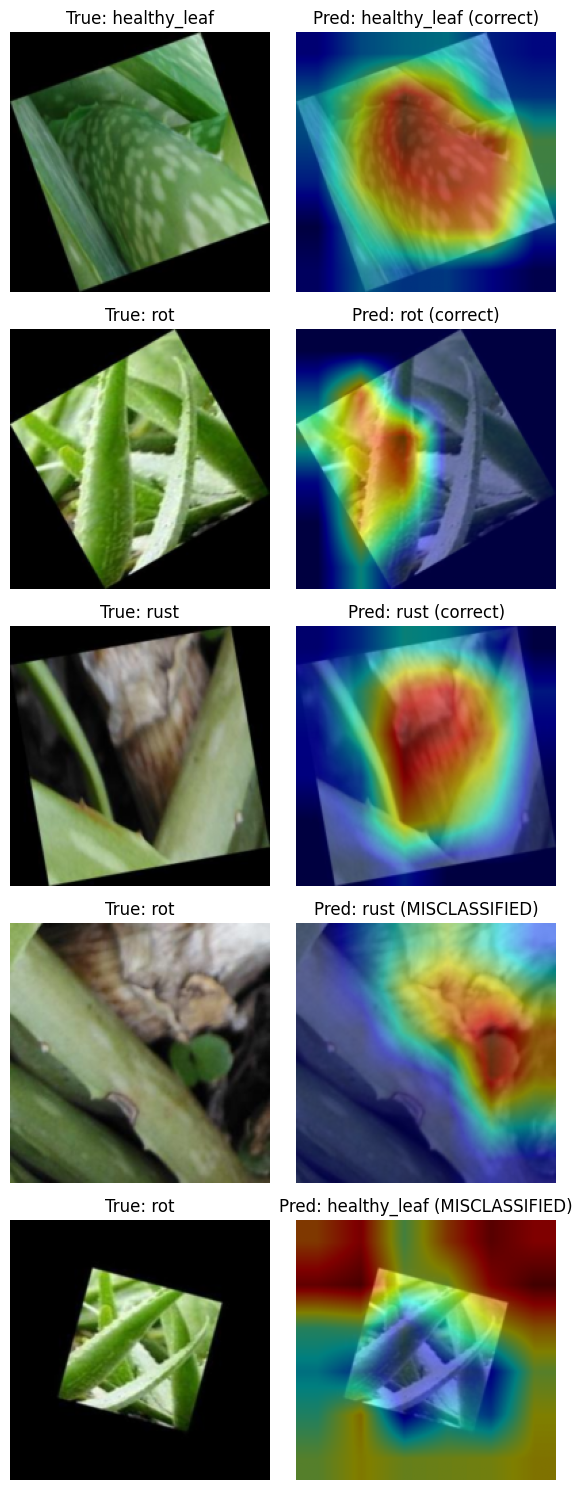

Saved to /kaggle/working/gradcam_examples.png


In [21]:
IMG_SIZE_FOR_DISPLAY = 192
display_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_FOR_DISPLAY, IMG_SIZE_FOR_DISPLAY)),
    transforms.ToTensor(),
])
display_view = datasets.ImageFolder(DATA_DIR, transform=display_transform)

misclassified = np.where(mnv2_preds != true_labels_flat)[0]
print(f"Misclassified by flat MobileNetV2: {len(misclassified)}")
print("True -> Predicted:", [(CLASS_NAMES[true_labels_flat[i]], CLASS_NAMES[mnv2_preds[i]]) for i in misclassified])

example_positions = []
for cls_idx in [0, 1, 2]:
    correct = np.where((true_labels_flat == cls_idx) & (mnv2_preds == cls_idx))[0]
    if len(correct) > 0:
        example_positions.append(("correct", correct[0]))
for pos in misclassified[:2]:
    example_positions.append(("misclassified", pos))

fig, axes = plt.subplots(len(example_positions), 2, figsize=(6, 3 * len(example_positions)))

for row, (tag, pos) in enumerate(example_positions):
    real_idx = test_idx[pos]
    true_label = true_labels_flat[pos]
    pred_label = mnv2_preds[pos]

    display_img, _ = display_view[real_idx]
    model_img, _ = eval_view[real_idx]

    cam = compute_gradcam(gradcam_model, model_img, target_class=int(pred_label))
    cam_resized = cv2.resize(cam, (display_img.shape[2], display_img.shape[1]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    img_np = display_img.permute(1, 2, 0).numpy()
    overlay = np.clip(0.5 * img_np + 0.5 * heatmap, 0, 1)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"True: {CLASS_NAMES[true_label]}")
    axes[row, 0].axis("off")

    status = "correct" if tag == "correct" else "MISCLASSIFIED"
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f"Pred: {CLASS_NAMES[pred_label]} ({status})")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_examples.png", dpi=200, bbox_inches="tight")
plt.show()

h1.remove()
h2.remove()
print("Saved to /kaggle/working/gradcam_examples.png")

In [22]:
!ls -la /kaggle/working/checkpoints

total 128900
drwxr-xr-x 2 root root     4096 Sep  9 18:57 .
drwxr-xr-x 4 root root     4096 Sep  9 18:59 ..
-rw-r--r-- 1 root root 16344965 Sep  9 18:44 efficientnet_b0_best.pt
-rw-r--r-- 1 root root 43360247 Sep  9 18:52 efficientnet_b3_best.pt
-rw-r--r-- 1 root root  9161227 Sep  9 18:40 mobilenetv2_100_best.pt
-rw-r--r-- 1 root root 44793291 Sep  9 18:47 resnet18_best.pt
-rw-r--r-- 1 root root  9159691 Sep  9 18:56 stage1_healthy_vs_diseased_best.pt
-rw-r--r-- 1 root root  9157131 Sep  9 18:58 stage2_rot_vs_rust_best.pt
